In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential, layers
from tensorflow.keras.layers import Dense, LSTM, Dropout, Bidirectional, Input, Conv1D, SimpleRNN, GRU
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.losses import MeanSquaredError as MSELoss
from tensorflow.keras.metrics import MeanAbsolutePercentageError as MAPEMetrics
from tensorflow.keras.metrics import MeanAbsoluteError as MAEMetrics
from tensorflow.keras.metrics import MeanSquaredError as MSEMetrics
tfk = tf.keras
tf.keras.backend.set_floatx("float32")
from tensorflow.keras.utils import timeseries_dataset_from_array as TDFA
import tensorflow_addons as tfa

import numpy as np
from scipy import stats
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer, KNNImputer
from statsmodels.tsa.seasonal import STL
from tools.preprocess_lib import * #library bang kris

import matplotlib.pyplot as plt
from matplotlib.ticker import (AutoMinorLocator, MultipleLocator)
#from datetime import datetime
import pandas as pd
import time
import csv
import os
import seaborn as sns
import pickle 

TRAIN_NAME = 'GRU_singleDense'

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
print("Num GPUs Available: ", len(gpus))

Num GPUs Available:  1


In [2]:
FILEINPUT = 'df_final'
DATA_PATH = f'./'
DATA_NAME = f'{FILEINPUT}.pkl'

df_data = pd.read_pickle(DATA_PATH + DATA_NAME)

In [3]:
df_data.head()

,House overall,temperature,humidity,apparentTemperature,pressure,cloudCover,windBearing,precipIntensity,dewPoint,precipProbability
time,,,,,,,,,,
2016-01-01 05:00:00,0.932833,36.14,0.62,29.26,1016.91,0.75,282.0,0.0,24.4,0.0
2016-01-01 05:01:00,0.934333,36.14,0.62,29.26,1016.91,0.75,282.0,0.0,24.4,0.0
2016-01-01 05:02:00,0.931817,36.14,0.62,29.26,1016.91,0.75,282.0,0.0,24.4,0.0
2016-01-01 05:03:00,1.022050,36.14,0.62,29.26,1016.91,0.75,282.0,0.0,24.4,0.0
2016-01-01 05:04:00,1.139400,36.14,0.62,29.26,1016.91,0.75,282.0,0.0,24.4,0.0


Data nullities:  False  | Data length:  503910
Data max value:  14.71456667  | Data min value:  0.0
Data variance:  1.119802812415163  | Data standard deviation:  1.0582073579479416
Data mean:  0.8589623950050781  | Data median:  0.562333333
Data nullities:  False  | Data length:  503910
Data max value:  93.72  | Data min value:  -12.64
Data variance:  365.33763678820054  | Data standard deviation:  19.113807490612658
Data mean:  50.741934611339325  | Data median:  50.32
Data nullities:  False  | Data length:  503910
Data max value:  0.98  | Data min value:  0.13
Data variance:  0.037786928386373604  | Data standard deviation:  0.1943886014826322
Data mean:  0.664085035026096  | Data median:  0.68
Data nullities:  False  | Data length:  503910
Data max value:  101.12  | Data min value:  -32.08
Data variance:  485.2290840711418  | Data standard deviation:  22.02791601743437
Data mean:  48.26338203250579  | Data median:  50.32
Data nullities:  False  | Data length:  503910
Data max value

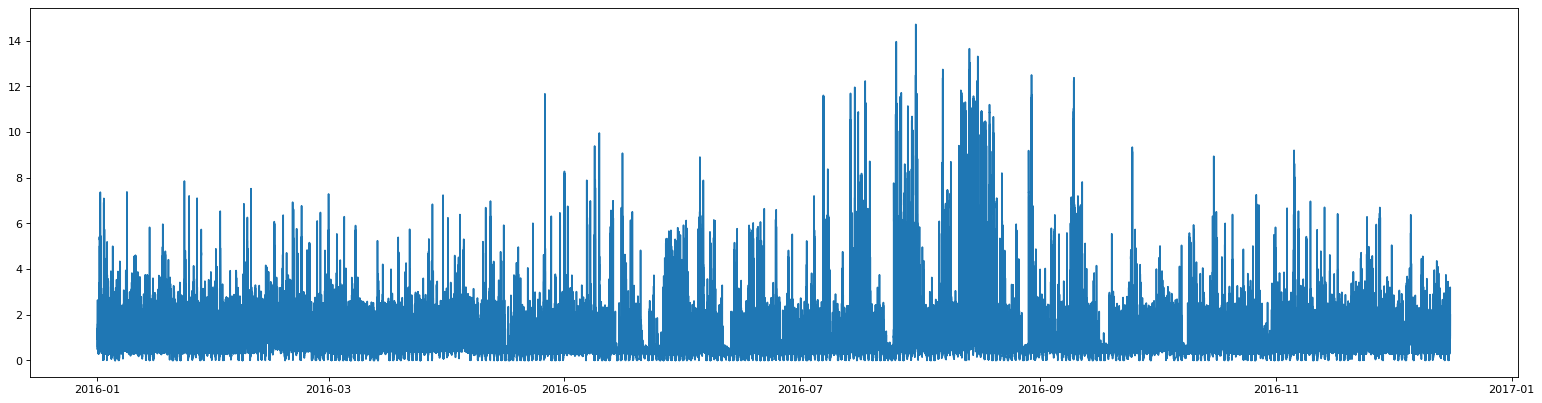

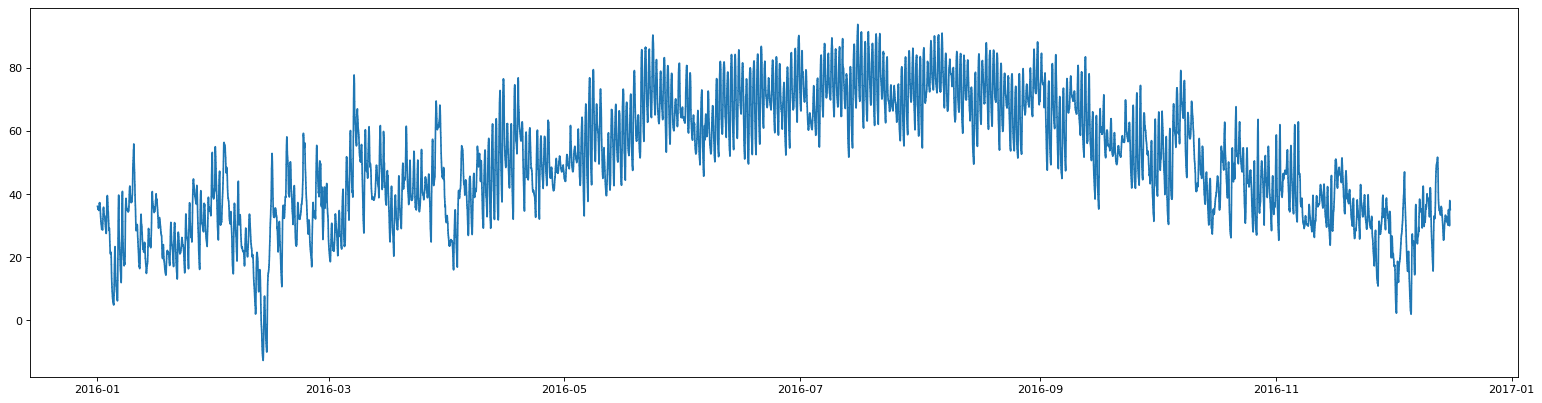

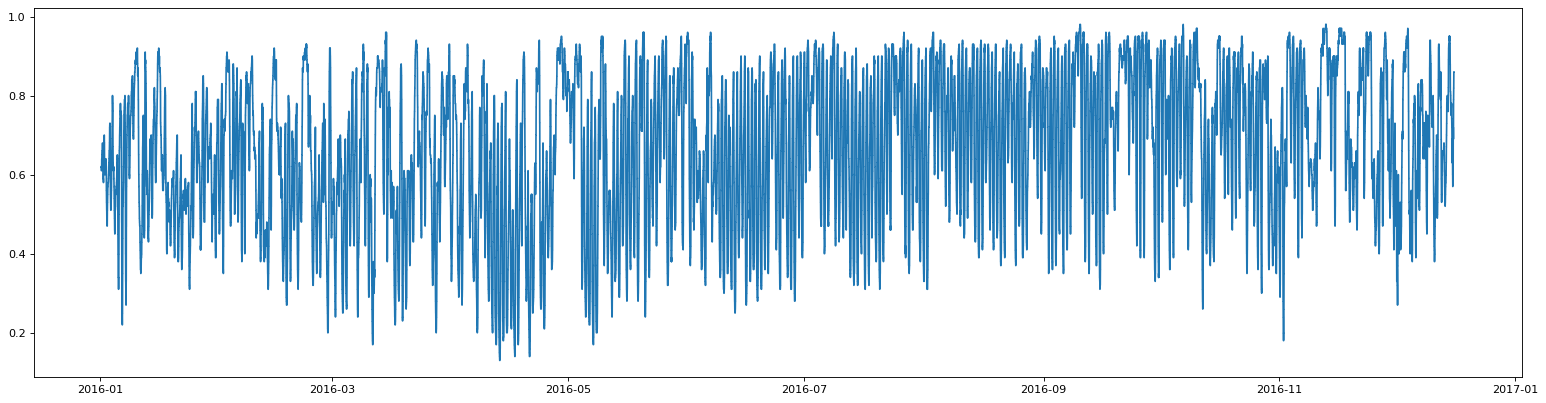

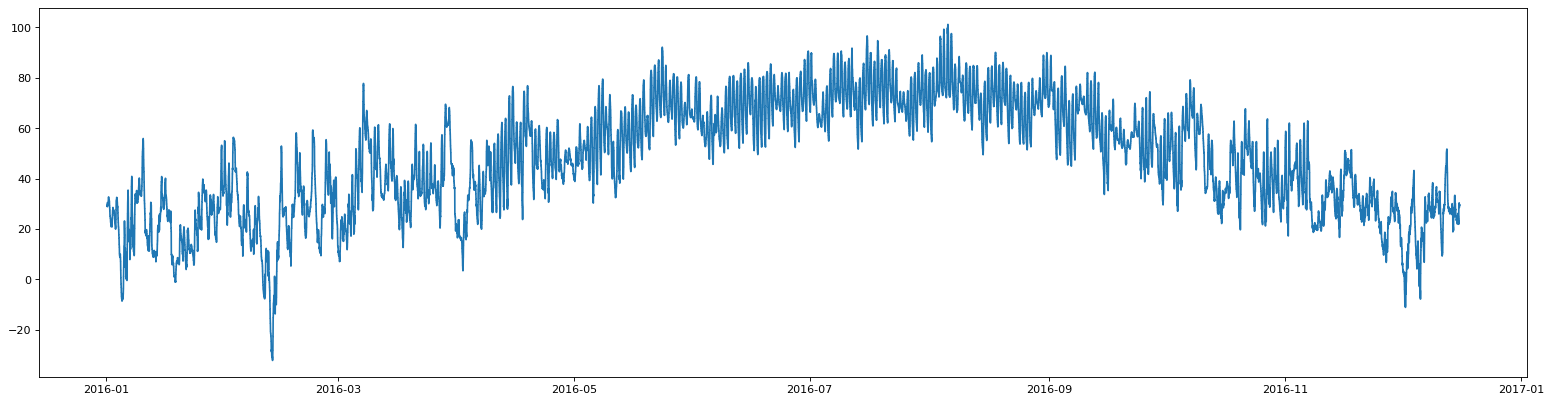

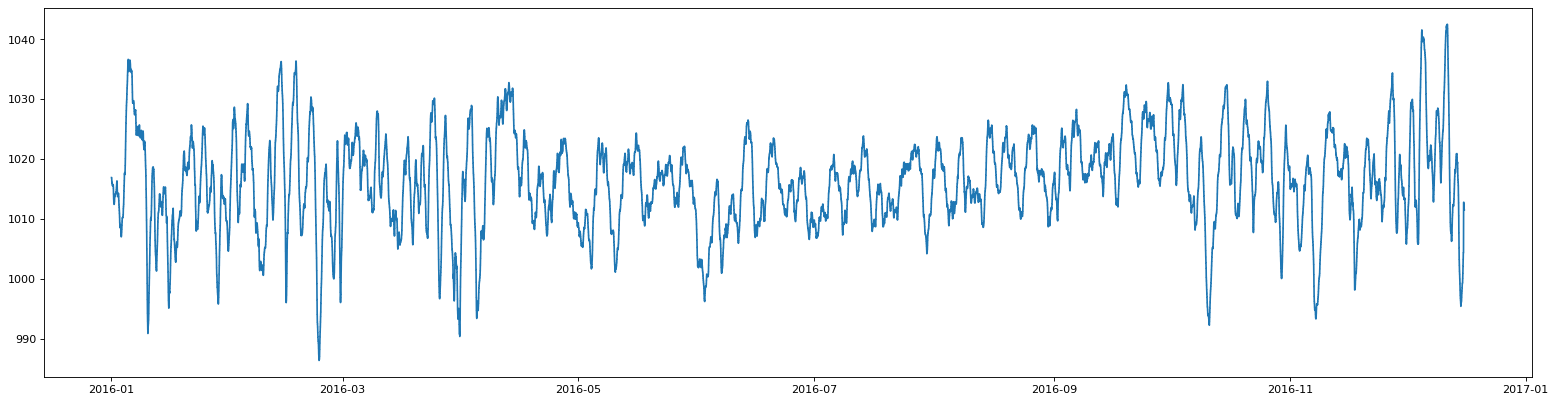

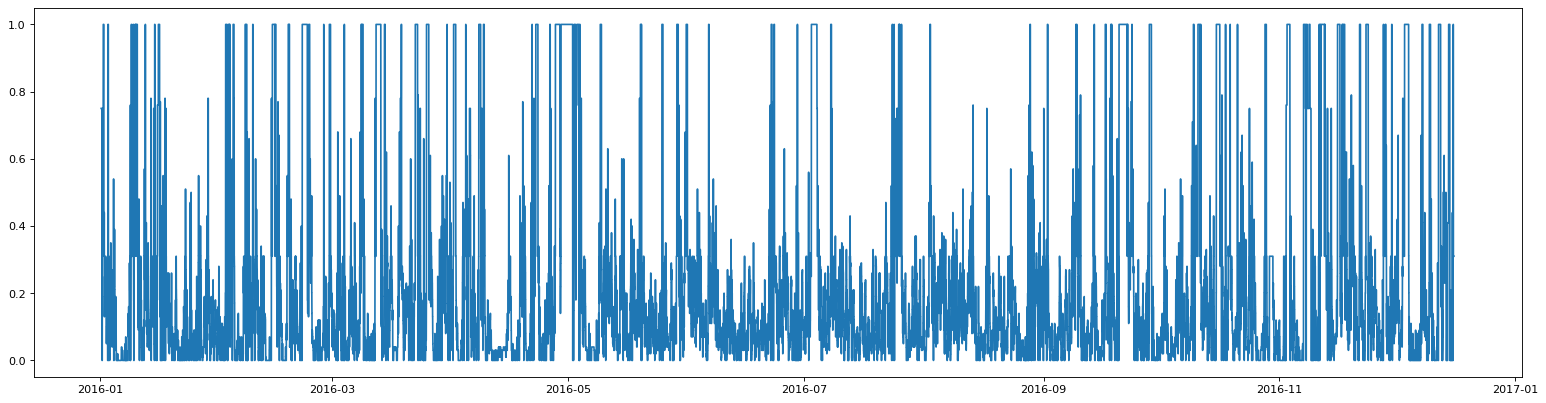

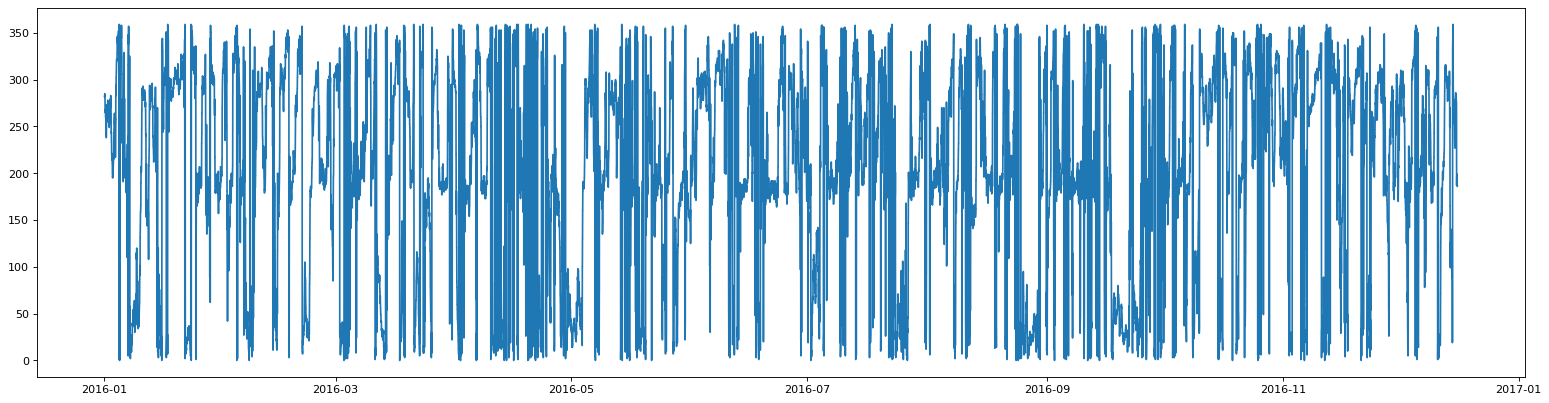

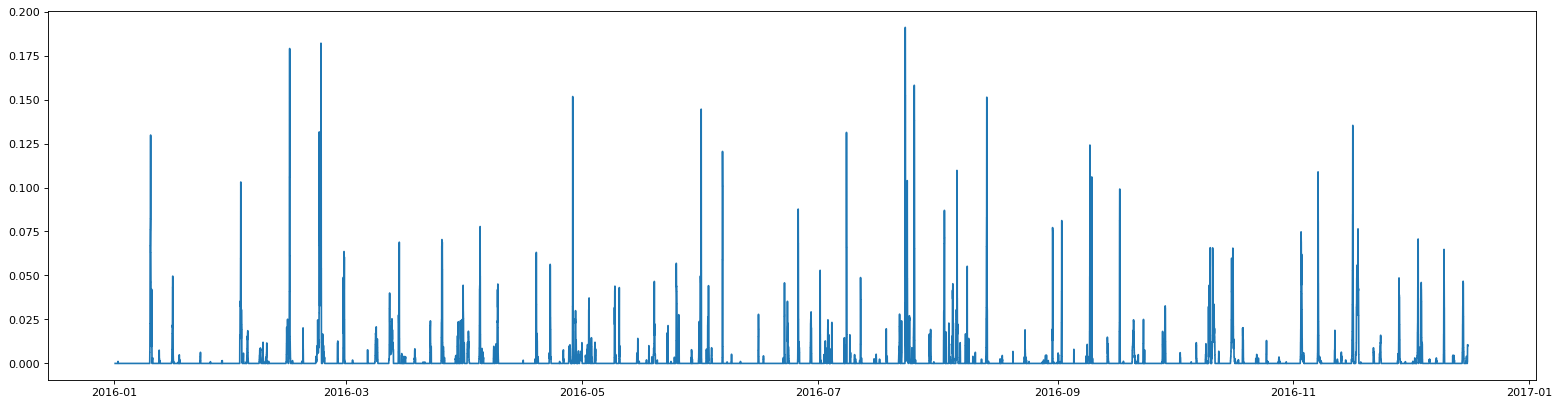

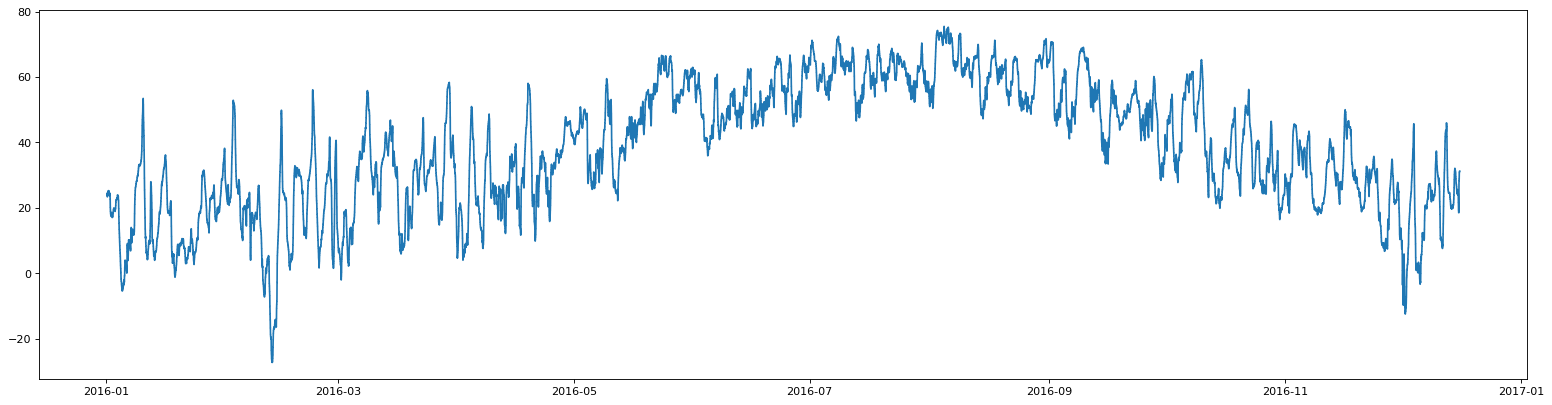

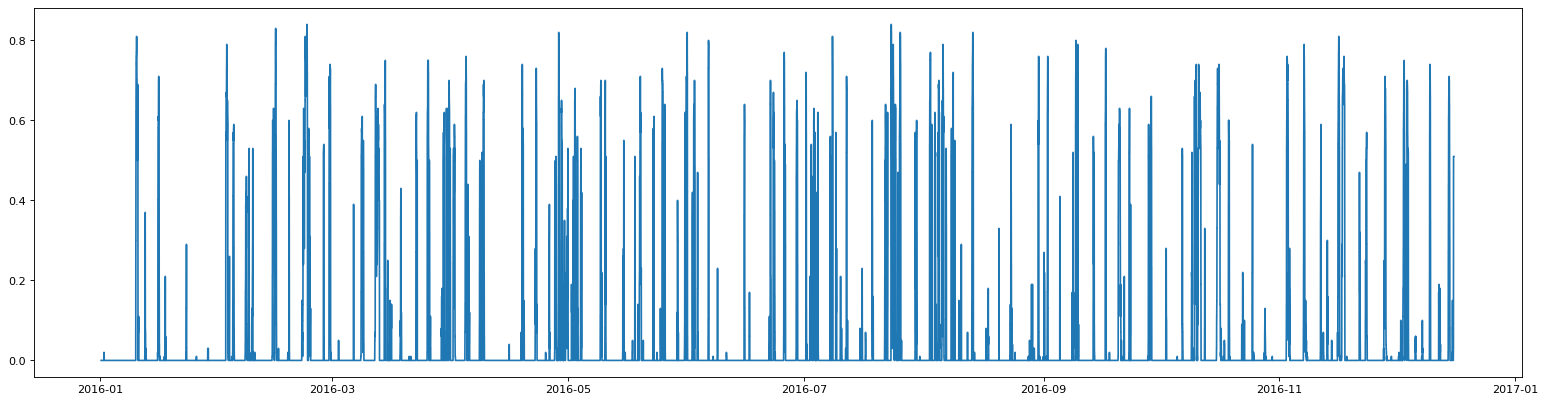

In [4]:
for columns in df_data:
    inspectData(df_data[columns])

In [5]:
df_data.std()

House overall            1.058207
temperature             19.113807
humidity                 0.194389
apparentTemperature     22.027916
pressure                 7.895185
cloudCover               0.289945
windBearing            106.520474
precipIntensity          0.011257
dewPoint                19.087939
precipProbability        0.165836
dtype: float64

In [6]:
np_data = df_data.to_numpy()

In [7]:
print(np_data.std(), np_data.mean())

301.39401182533294 135.81658421052683


In [8]:
VAL_LENGTH = 0.2
LABELS_LENGTH = (24*7) + 24 #1 week
SEQ_LENGTH = 24 #1 day
DATA_FEATURES = 10
BATCH_SIZE = 32

MIU = 1e-3
EPOCH = 200
VAL_LENGTH = 0.2

In [9]:
train_size = int((len(df_data)-LABELS_LENGTH) * (1-VAL_LENGTH))
val_size = int((len(df_data) - LABELS_LENGTH) - train_size)
print('\nData length: ', len(df_data), '\nTrain data size: ', train_size, '\nVal data size: ', val_size)

# VARIANT 1
df_train = pd.DataFrame(df_data.iloc[0:train_size, :])
df_valid = pd.DataFrame(df_data.iloc[train_size:train_size+val_size, :])
df_test = pd.DataFrame(df_data.iloc[train_size+val_size:, :])

print('\nData length: ', len(df_train), '\nData head: ', df_train.head(), '\nData tail: ', df_train.tail())
print('\nData length: ', len(df_valid), '\nData head: ', df_valid.head(), '\nData tail: ', df_valid.tail())


Data length:  503910 
Train data size:  402974 
Val data size:  100744

Data length:  402974 
Data head:                       House overall  temperature  humidity  \
time                                                        
2016-01-01 05:00:00       0.932833        36.14      0.62   
2016-01-01 05:01:00       0.934333        36.14      0.62   
2016-01-01 05:02:00       0.931817        36.14      0.62   
2016-01-01 05:03:00       1.022050        36.14      0.62   
2016-01-01 05:04:00       1.139400        36.14      0.62   

                     apparentTemperature  pressure  cloudCover  windBearing  \
time                                                                          
2016-01-01 05:00:00                29.26   1016.91        0.75        282.0   
2016-01-01 05:01:00                29.26   1016.91        0.75        282.0   
2016-01-01 05:02:00                29.26   1016.91        0.75        282.0   
2016-01-01 05:03:00                29.26   1016.91        0.75        

In [10]:
np_train = df_train.to_numpy()
np_valid = df_valid.to_numpy()
np_test = df_test.to_numpy()

X_train, y_train = create_dataset(np_train,np_train[:,0],SEQ_LENGTH)
X_valid, y_valid = create_dataset(np_valid,np_valid[:,0],SEQ_LENGTH)
X_test, y_test = create_dataset(np_test,np_test[:,0],SEQ_LENGTH)

In [11]:
print(X_train.shape)
print(y_train.shape)
print(X_valid.shape)
print(y_valid.shape)

(402950, 24, 10)
(402950,)
(100720, 24, 10)
(100720,)


In [12]:
def create_model(units):
    model = Sequential()
    model.add(Input(shape=(SEQ_LENGTH, DATA_FEATURES)))
#     model.add(Conv1D(filters=128,kernel_size=3,padding='same',activation='tanh'))
#     model.add(Conv1D(filters=256,kernel_size=3,padding='same',activation='tanh'))
    # model.add(LSTM(units = units, return_sequences=True, input_shape=[SEQ_LENGTH, DATA_FEATURES]))
#     model.add(Bidirectional(LSTM(units = units*2, return_sequences=False)))
#     model.add(Bidirectional(LSTM(units = units*4, return_sequences=False)))
    #model.add(LSTM(units = units*5, return_sequences=True))
    #model.add(LSTM(units = units*10))
#     model.add(Dense(units=2,activation='tanh'))
    model.add(GRU(units = units*2, return_sequences=False))
    model.add(Dense(units=1,activation='tanh'))

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=MIU),
                  loss='mse',
                  metrics=[MAEMetrics(), MSEMetrics(), MAPEMetrics(), tf.nn.log_poisson_loss, tfa.metrics.RSquare()])
    return model

model_build = create_model(SEQ_LENGTH)

In [13]:
model_build.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional (Bidirectiona  (None, 24, 96)           22656     
 l)                                                              
                                                                 
 bidirectional_1 (Bidirectio  (None, 192)              148224    
 nal)                                                            
                                                                 
 dense (Dense)               (None, 1)                 193       
                                                                 
Total params: 171,073
Trainable params: 171,073
Non-trainable params: 0
_________________________________________________________________


In [14]:
checkpoint_path = f'checkpoint/{TRAIN_NAME}/' + TRAIN_NAME

cp_callback = ModelCheckpoint(checkpoint_path, monitor='val_loss', verbose=1, save_best_only=True, save_weights_only=True)
earlystop_callback = EarlyStopping(monitor='loss', min_delta=0.000001, patience=20)
hist_callback = tf.keras.callbacks.History()
reduceLR_callback = ReduceLROnPlateau(monitor='val_loss', factor=0.005, patience=5, verbose=1, min_delta=1e-8)

In [15]:
def fit_model(model):
    history = model.fit(X_train, y_train, epochs=EPOCH,  
                        validation_data=(X_valid, y_valid),
                        batch_size=BATCH_SIZE, shuffle=True,
                        callbacks=[cp_callback, hist_callback, earlystop_callback, reduceLR_callback])
#                         callbacks=[cp_callback, hist_callback, reduceLR_callback])
    return history

In [ ]:
start_time = time.time()
st_time = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
st_time2 = datetime.now().strftime('%Y%m%d %H%M%S')
print('Start time: ', datetime.now())

tele_messages = {
        'Train Name': TRAIN_NAME,
        'Train Started': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'Input Data': DATA_NAME,
    }
bot.send_message(tele_messages)

train_history = fit_model(model_build)

print('Start time: ', st_time, '\nFinished time: ', datetime.now().strftime('%Y-%m-%d %H:%M:%S'))
print('Overall training time: ', (time.time()-start_time)/3600, ' hours')

Start time:  2022-12-20 18:38:14.270088
Epoch 1/200
12591/12593 [============================>.] - ETA: 0s - loss: 1.2881 - mean_absolute_error: 0.6083 - mean_squared_error: 1.2881 - mean_absolute_percentage_error: 2976.0095 - log_poisson_loss: 1.6491 - r_square: 0.0023
Epoch 1: val_loss improved from inf to 0.45249, saving model to checkpoint/Stacked_BiLSTM_singleDense\Stacked_BiLSTM_singleDense
12593/12593 [==============================] - 261s 20ms/step - loss: 1.2881 - mean_absolute_error: 0.6083 - mean_squared_error: 1.2881 - mean_absolute_percentage_error: 2975.7498 - log_poisson_loss: 1.6492 - r_square: 0.0023 - val_loss: 0.4525 - val_mean_absolute_error: 0.5022 - val_mean_squared_error: 0.4525 - val_mean_absolute_percentage_error: 471.0120 - val_log_poisson_loss: 1.8115 - val_r_square: -0.0477 - lr: 0.0010
Epoch 2/200
12591/12593 [============================>.] - ETA: 0s - loss: 1.2927 - mean_absolute_error: 0.6126 - mean_squared_error: 1.2927 - mean_absolute_percentage_error

In [ ]:
tele_messages = {
        'Train Name': TRAIN_NAME,
        'Input Data': DATA_NAME,
        'Train Finished' :  datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'Train Time' : (time.time()-start_time)/3600,
        'MSE': min(train_history.history['mean_squared_error']),
        'MAE': min(train_history.history['mean_absolute_error']),
        'MAPE': min(train_history.history['mean_absolute_percentage_error']),
        'R Square': max(train_history.history['r_square']),
        'Val MSE': min(train_history.history['val_mean_squared_error']),
        'Val MAE': min(train_history.history['val_mean_absolute_error']),
        'Val MAPE': min(train_history.history['val_mean_absolute_percentage_error']),
        'Val R Square': max(train_history.history['val_r_square']),
        'Saved to checkpoint' : checkpoint_path,
    }

bot.send_message(tele_messages)

In [ ]:
# print(model_name + ':')
print('Mean Square Error (MSE): {:.4f}'.format(min(train_history.history['mean_squared_error'])))
print('Mean Absolute Error (MAE): {:.4f}'.format(min(train_history.history['mean_absolute_error'])))
print('Mean Absolute Percentage Error (MAPE): {:.4f}'.format(min(train_history.history['mean_absolute_percentage_error'])))
print('Coefficient of determination (R2): {:.4f}'.format(max(train_history.history['r_square'])))
print('Val Mean Square Error (MSE): {:.4f}'.format(min(train_history.history['val_mean_squared_error'])))
print('Val Mean Absolute Error (MAE): {:.4f}'.format(min(train_history.history['val_mean_absolute_error'])))
print('Val Mean Absolute Percentage Error (MAPE): {:.4f}'.format(min(train_history.history['val_mean_absolute_percentage_error'])))
print('Val Coefficient of determination (R2): {:.4f}'.format(max(train_history.history['val_r_square'])))

In [ ]:
import os
if not os.path.exists(f'train_loss_plot/{TRAIN_NAME}/'):
   os.makedirs(f'train_loss_plot/{TRAIN_NAME}/')
if not os.path.exists(f'result/{TRAIN_NAME}/'):
   os.makedirs(f'result/{TRAIN_NAME}/')

In [ ]:
def plot_loss (history, model_name):
    fig, ax= plt.subplots(figsize = (10, 6))
    ax.set_xlim(0, len(history.history['loss'])-1)
#     ax.set_ylim(0, 1)
    ax.tick_params(axis="y",direction="in")
    ax.tick_params(axis="x",direction="in")
    ax.xaxis.set_major_locator(MultipleLocator(0.1*len(history.history['loss'])))
#     ax.yaxis.set_major_locator(MultipleLocator(.2))
    
    plt.plot(history.history['loss'],linewidth=2)
    plt.plot(history.history['val_loss'],linewidth=2)
    csfont = {'fontname':'Times New Roman'}
    plt.title(TRAIN_NAME + ' ' + DATA_NAME)
    plt.ylabel('Loss',fontsize=14,**csfont)
    plt.xlabel('epoch',fontsize=14,**csfont)
    plt.legend(['Train loss', 'Validation loss'], loc='upper right',fontsize=12)
    plt.savefig(IMG_PATH + TRAIN_NAME + '_' + DATA_NAME + '_' + st_time2 + '.jpg')
    bot.send_image(IMG_PATH + TRAIN_NAME + '_' + DATA_NAME + '_' + st_time2 + '.jpg', caption='LOSS PLOT ' + TRAIN_NAME + ' ' + DATA_NAME)

IMG_PATH = f'train_loss_plot/{TRAIN_NAME}/'
plot_loss(train_history, TRAIN_NAME)

In [ ]:
model_build.load_weights(checkpoint_path)

In [ ]:
def prediction(model, iteration, X_test):
#     prediction = np.empty(shape=(iteration, len(X_test), 1))
    
#     for k in range(iteration):
    prediction = model.predict(X_test)
    return prediction

prediction_result = prediction(model_build, 10, X_test)

In [ ]:
prediction_result.shape

In [ ]:
pred = prediction_result

In [ ]:
def plot_future(prediction, model_name, y_test):
    fig, ax= plt.subplots(figsize = (12, 8))
    ax.set_xlim(0, y_test.shape[0])
#     ax.set_ylim(0, 1)
    ax.tick_params(axis="y",direction="in")
    ax.tick_params(axis="x",direction="in")
    ax.xaxis.set_major_locator(MultipleLocator(0.1*y_test.shape[0]))
#     ax.yaxis.set_major_locator(MultipleLocator(.2)
    csfont = {'fontname':'Times New Roman'}
    range_future = len(prediction)
    plt.plot(np.arange(range_future), np.array(y_test),  label='Test data',linewidth=2)
    plt.plot(np.arange(range_future),np.array(prediction),label='Prediction',linewidth=2)
#     plt.title('Test data vs prediction for ' + model_name)
    plt.legend(loc='upper left',fontsize=14)
    plt.xlabel('Time (Hour)',fontsize=16,**csfont)
    plt.ylabel('Normalized p (kWh)',fontsize=16,**csfont)
    plt.savefig(IMG_PATH + 'PREDICTION RESULT_' + TRAIN_NAME + '_' + DATA_NAME + '_' + st_time2 + '.jpg')
    bot.send_image(IMG_PATH + 'PREDICTION RESULT_' + TRAIN_NAME + '_' + DATA_NAME + '_' + st_time2 + '.jpg', caption='PREDICTION PLOT ' + TRAIN_NAME + ' ' + DATA_NAME)

plot_future(pred[:24*7], TRAIN_NAME, y_test[:24*7])

In [ ]:
from sklearn.metrics import r2_score
def smapeCalc(A, F):
    return 100/len(A) * np.sum(np.abs(F - A) / ((np.abs(A) + np.abs(F))/2))

def evaluate_prediction(predictions, actual, model_name):
    # dif=predictions-actual
    # errors = np.nan_to_num(dif, nan=0)
    # mse = np.square(errors).mean()*100
    # rmse = np.sqrt(mse)*100
    # mae = np.abs(errors).mean()
    # mape = np.abs(errors).mean()*100
    mse = mean_squared_error(predictions,actual)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(predictions,actual)
    smape = smapeCalc(predictions,actual)
    mape = mean_absolute_percentage_error(predictions,actual)
    r2=r2_score(predictions,actual)
    print(model_name + ':')
    print('Mean Square Error (MSE): {:.4f}'.format(mse))
    print('Root Mean Square Error (NRMSE): {:.4f}'.format(rmse))
    print('Mean Absolute Error (MAE): {:.4f}'.format(mae))
    print('Symmetric Mean Absolute Percentage Error (SMAPE): {:.4f}'.format(smape))
    print('Mean Absolute Percentage Error (MAPE): {:.4f}'.format(mape))
    print('Coefficient of determination (R2): {:.4f}'.format(r2))
    return smape, mse, rmse, mae, mape, r2

smape, mse, rmse, mae, mape, r2 = evaluate_prediction(pred, y_test, TRAIN_NAME)

In [ ]:
tele_messages = {
        'PREDICTION TEST RESULT': TRAIN_NAME,
        'Train Name': TRAIN_NAME,
        'Input Data': DATA_NAME,
        'MSE': mse,
        'MAE': mae,
        'MAPE': mape,
        'R Square': r2,
        'RMSE': rmse,
    }

bot.send_message(tele_messages)

In [ ]:
column = 2
row = len(train_history.history['loss'])
store = np.zeros((row,column))
j = 0

for k in train_history.history['loss']:
    store[j,0] = k
    j+=1

j = 0
for k in train_history.history['val_loss']:
    store[j,1] = k
    j+=1
    
df = pd.DataFrame(store)

filename = f'result/{TRAIN_NAME}/' + TRAIN_NAME + '_' + DATA_NAME + '-loss_valLoss.csv'
df.to_csv(filename, index=False, header=['loss', 'val_loss'])

In [ ]:
column = 5
row = len(train_history.history['mean_absolute_error'])
store = np.zeros((row,column))
j = 0

for k in train_history.history['mean_absolute_error']:
    store[j,0] = k
    j+=1

j = 0
for k in train_history.history['mean_squared_error']:
    store[j,1] = k
    j+=1
    
j = 0
for k in train_history.history['mean_absolute_percentage_error']:
    store[j,2] = k
    j+=1
    
j = 0
for k in train_history.history['log_poisson_loss']:
    store[j,3] = k
    j+=1
    
j = 0
for k in train_history.history['r_square']:
    store[j,4] = k
    j+=1
    
df = pd.DataFrame(store)

filename = f'result/{TRAIN_NAME}/'+ TRAIN_NAME + '_' + DATA_NAME + '-train_metrics.csv'
df.to_csv(filename, index=False, header=['mean_absolute_error', 'mean_square_error', 'mean_absolute_percentage_error', 'log_poisson_loss', 'r_square'])

In [ ]:
column = 5
row = len(train_history.history['val_mean_absolute_error'])
store = np.zeros((row,column))
j = 0

for k in train_history.history['val_mean_absolute_error']:
    store[j,0] = k
    j+=1

j = 0
for k in train_history.history['val_mean_squared_error']:
    store[j,1] = k
    j+=1
    
j = 0
for k in train_history.history['val_mean_absolute_percentage_error']:
    store[j,2] = k
    j+=1
    
j = 0
for k in train_history.history['val_log_poisson_loss']:
    store[j,3] = k
    j+=1
    
j = 0
for k in train_history.history['val_r_square']:
    store[j,4] = k
    j+=1
    
df = pd.DataFrame(store)

filename = f'result/{TRAIN_NAME}/'+ TRAIN_NAME + '_' + DATA_NAME + '-val_metrics.csv'
df.to_csv(filename, index=False, header=['val_mean_absolute_error', 'val_mean_square_error', 'val_mean_absolute_percentage_error', 'val_log_poisson_loss', 'val_r_square'])

In [ ]:
column = 2
row = len(pred)
store = np.zeros((row,column))
j = 0

for k in pred:
    store[j,0] = k
    j+=1

j = 0
for k in y_test:
    store[j,1] = k
    j+=1
    
df = pd.DataFrame(store)

filename = f'result/{DATA_NAME}/{TRAIN_NAME}/'+ TRAIN_NAME + '_' + DATA_NAME + '-test_prediction.csv'
df.to_csv(filename, index=False, header=['pred', 'y_test'])

In [ ]:
metList = ['MSE', 'MAE', 'MAPE', 'R Square', 'RMSE', mse, mae, mape, r2, rmse]
filename = f'result/{TRAIN_NAME}/'+ TRAIN_NAME + '_' + DATA_NAME + '-test_metrics.csv'
pd.DataFrame(metList).to_csv(filename)